In [1]:
import os 
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch 
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
from omegaconf import OmegaConf
import torch 
import numpy as np
import random
from comp_predictive_learning.models import create_model
import hydra
import logging
from collections import defaultdict
from comp_predictive_learning.datasets import make_sketch_dataloaders
from comp_predictive_learning.utils.train_loop import train_loop
from comp_predictive_learning.utils.make_all_sketch_plots import make_all_plots
logger = logging.getLogger(__name__)


In [2]:

def set_seed(seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

np.set_printoptions(precision=5, suppress=True, linewidth=200)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [3]:
from hydra import initialize, initialize_config_module, initialize_config_dir, compose

with initialize_config_dir(version_base=None, config_dir="/home/ghb24/comp_predictive_learning/scripts/configs/"):
    config = compose(config_name="train_rnn.yaml")


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'train_rnn.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
set_seed(config.seed)   
pretrain_loader,val_loader, smaller_pretrain_loader,analysis_loader,classification_metric_train_loaders, classification_metric_val_loaders,latent_names, train_contexts,val_contexts = make_sketch_dataloaders(config)

all_contexts = train_contexts + val_contexts

model = create_model(config).to(DEVICE)


--- Generating Support: 'full' ---
Total contexts: 54
Train contexts: 43
Validation contexts: 11
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 512 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 512 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 512 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 512 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 512 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 512 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 512 random drawings.
Using primitives: ['h

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Contexts:  tensor([[2, 1, 1, 0],
        [3, 1, 0, 0],
        [2, 0, 1, 0],
        [2, 2, 1, 0],
        [3, 1, 1, 0],
        [3, 1, 2, 0],
        [1, 2, 1, 0],
        [0, 0, 2, 0],
        [2, 2, 2, 0],
    

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU2 NVIDIA GeForce GTX TITAN X which is of cuda capability 5.2.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  warnings.warn(
/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/cuda/__init__.py:304: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  warnings.warn(matched_cuda_warn.format(matched_arches))
/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/cuda/__init__.py:326: UserWarning: 
NVIDIA GeForce GTX TITAN X with CUDA capability sm_52 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the NVIDIA GeForce GTX TITAN X GPU with PyTorch, please 

In [6]:
    

# print(model)
# optimizer = torch.optim.AdamW(model.parameters(),lr=config.train_loop.pretrain_lr,weight_decay=config.train_loop.pretrain_decay)

# logger.info("-----------------")
# logger.info("Pretraining")
# logger.info("-----------------")

# metrics = defaultdict(list)

# logging_groups =  {}
    
# model,training_losses, validation_losses, metrics = train_loop(config,
#                                                             pretrain_loader,
#                                                             val_loader,
#                                                             smaller_pretrain_loader,
#                                                             analysis_loader,
#                                                             model,
#                                                             optimizer,
#                                                             all_contexts,
#                                                             latent_names,
#                                                             classification_metric_train_loaders,
#                                                             classification_metric_val_loaders,
#                                                             logger=print)
    


In [7]:
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_256_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/review/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16_[1]/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/False/ae_mem_1/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0_0_0_128/seed0/model_step_4999.pth"))
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6_4/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

<All keys matched successfully>

In [15]:
batch = next(iter(val_loader))


In [16]:
outs = model(batch[0])[0]

In [17]:
inps = batch[0][:,b].cpu().numpy()
outs = outs.cpu().detach().numpy()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.021268332..0.026621956].


t 0


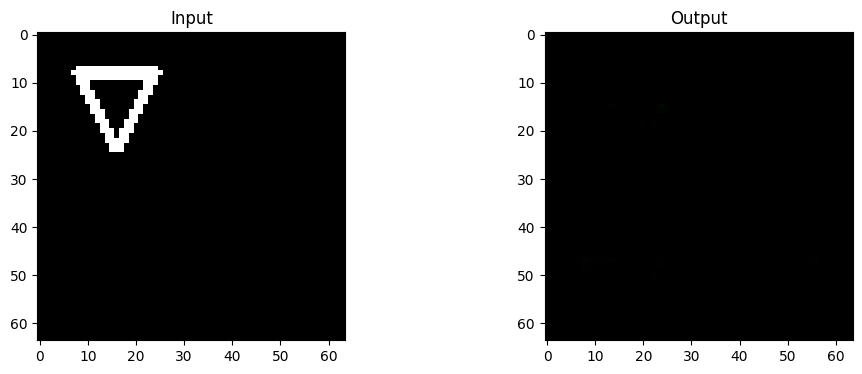

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22731237..1.2438581].


t 1


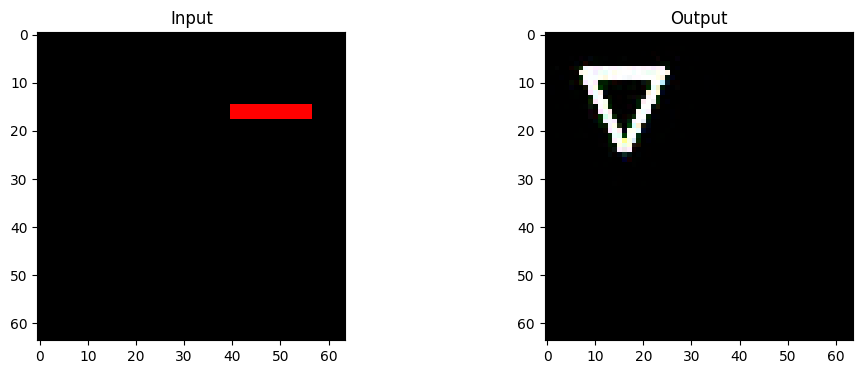

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13958217..0.9186048].


t 2


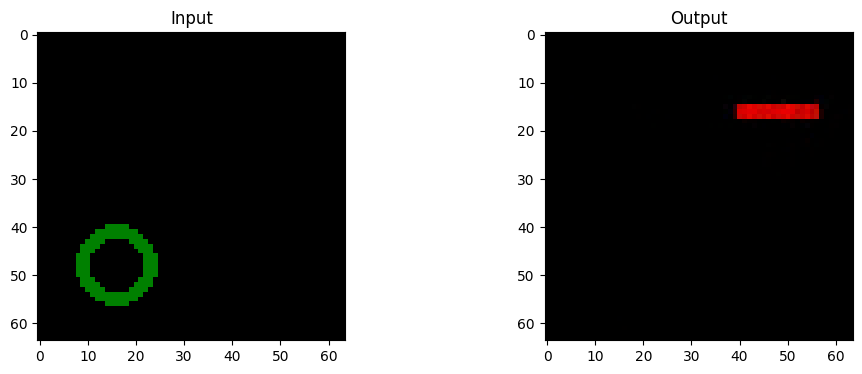

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16380419..0.5493414].


t 3


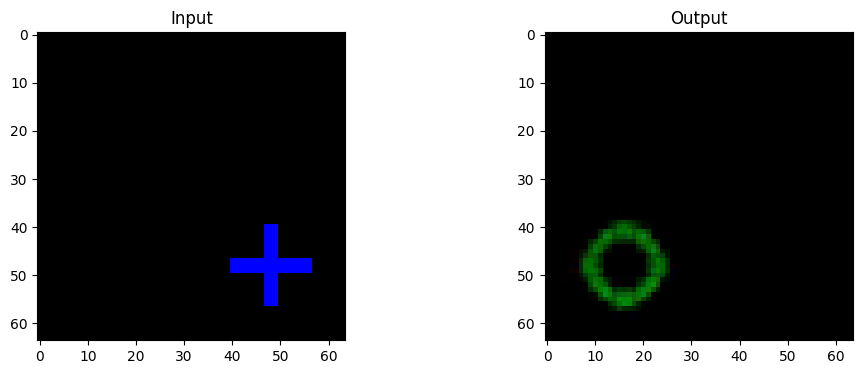

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23078541..1.1836213].


t 4


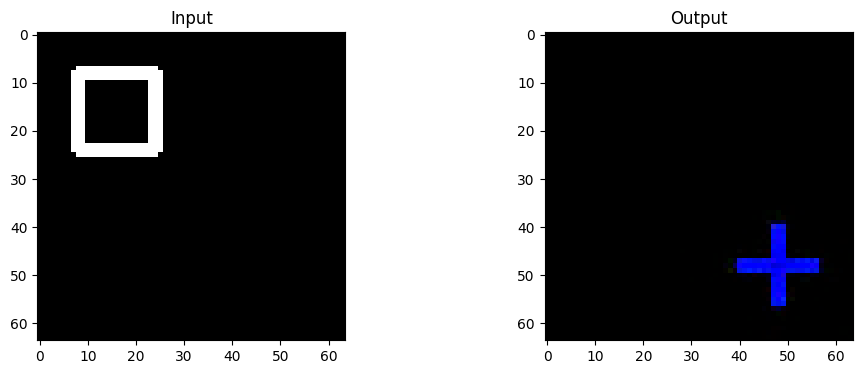

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15815403..1.1583161].


t 5


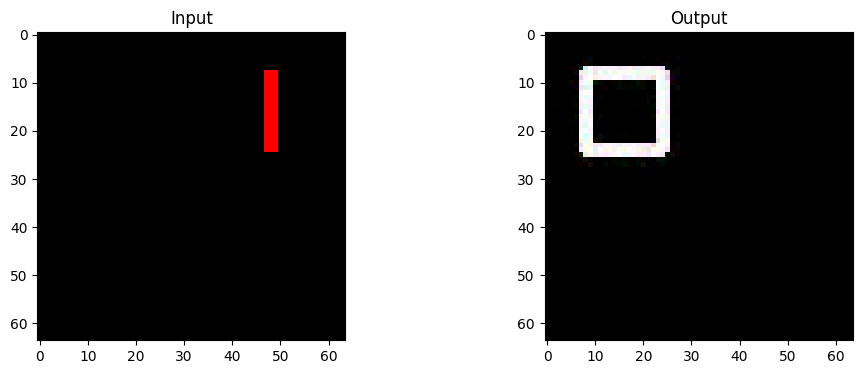

In [18]:
import matplotlib.pyplot as plt 
b = 0
outs = outs[:,b]
for t in range(inps.shape[0]):
    print("t", t)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Input")
    plt.imshow(inps[t].transpose(1,2,0))
    plt.subplot(1, 2, 2)
    plt.title("Output")
    plt.imshow(outs[t].transpose(1,2,0))
    plt.show()

In [6]:
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_256_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/disi/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred_1/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.01_0.01_0_0_128/seed0/model_step_4999.pth"))
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6_4/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

/tmp/ipykernel_2377023/2314615570.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/disi/contextual_

<All keys matched successfully>

Output shape from conv layers 1024
Optimal number of clusters: 12, Silhouette scores: [0.11656 0.12593 0.13772 0.15386 0.17189 0.19292 0.21536 0.22832 0.23868 0.26057 0.27213 0.2664  0.26942 0.26901 0.2703  0.26358 0.25715 0.25632 0.26571 0.25492 0.24447 0.24802 0.25704]


(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Neuron Clusters', ylabel='Contexts'>)

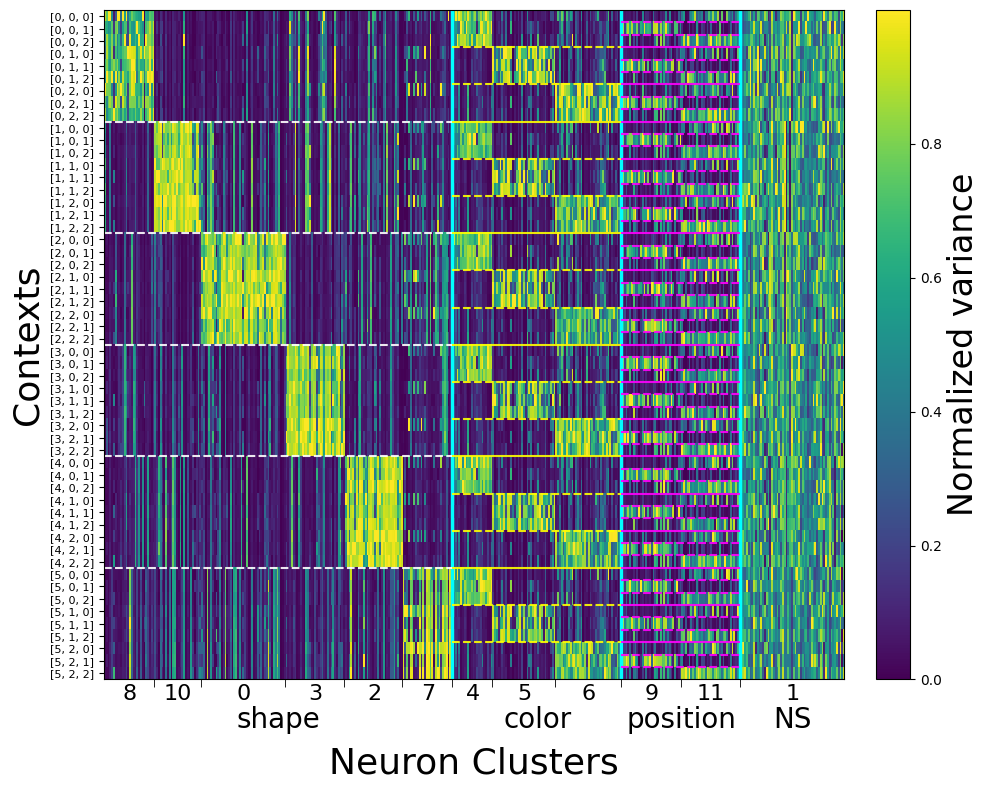

In [7]:
import matplotlib.pyplot as plt
from comp_predictive_learning.metrics.clustering import get_rnn_activities_and_sources_for_loader_for_clustering, get_optimal_n_cluster, analyze_and_sort_clusters, plot_sequentially_sorted_clusters

activations, contexts = get_rnn_activities_and_sources_for_loader_for_clustering(model, analysis_loader)
max_num_clusters, scores, norm_var_activities_per_context, active_units, labels = get_optimal_n_cluster(model, activations=activations, contexts=contexts, time_variance=False, device=DEVICE)
unique_contexts, inv = contexts.unique(dim=0, return_inverse=True)

print(f"Optimal number of clusters: {max_num_clusters}, Silhouette scores: {scores}")

(sorted_order, group_labels, group_boundaries,
peak_map, informative_indices, cluster_profiles) = analyze_and_sort_clusters(
    norm_var_activities_per_context=norm_var_activities_per_context.cpu().numpy(),
    contexts_unique=unique_contexts.cpu(),
    labels=labels,
    selectivity_threshold= 0.2,
    purity_threshold= 0.5
)
fig_cluster,ax_cluster = plt.subplots(1, 1, figsize=(10, 8))

plot_sequentially_sorted_clusters(
    norm_var_activities_per_context=norm_var_activities_per_context.cpu().numpy(),
    contexts_unique=unique_contexts.cpu(),
    labels=labels,
    final_cluster_order=sorted_order,
    group_labels=group_labels,
    group_boundaries_by_cluster_count=group_boundaries,
    group_name_map={"C0":"shape","C1":"color","C2":"position"},
    put_y_label= not "auto" in config.model.type,
    fig=fig_cluster,
    ax=ax_cluster
)


In [ ]:
from comp_predictive_learning.metrics.clustering import computer_lesioned_cluster_losses,plot_cluster_lesion_delta

fig_lesion,ax_lesion = plt.subplots(1, 1, figsize=(10, 8))
cluster_losses, original_network_losses,cluster_to_neurons = computer_lesioned_cluster_losses(model,
                                                                        dataloader=analysis_loader,
                                                                        active_units=active_units,
                                                                        labels=labels,
                                                                        number_of_clusters=max_num_clusters)

plot_cluster_lesion_delta(
    original_network_losses=original_network_losses,
    lesioned_cluster_loss=cluster_losses,
    cluster_order=sorted_order, 
    put_y_label= not "auto" in config.model.type,
    fig=fig_lesion,
    ax=ax_lesion)


In [8]:
original_indices = np.where(active_units)[0]
cluster_to_neurons = {}
for i, cluster_id in enumerate(np.unique(labels)):
    neurons_in_cluster_mask = labels == cluster_id
    cluster_to_neurons[cluster_id] = original_indices[neurons_in_cluster_mask]

all_neurons_groups = {}
for k in cluster_to_neurons:
    all_neurons_groups[str(k)] = cluster_to_neurons[k]

for k in all_neurons_groups:
    print(f"Group {k} has {(all_neurons_groups[k])} neurons")
    
context_to_cluster = {}
curr_idx = 0
for i, gl in enumerate(group_labels):
    context_to_cluster[gl] = []
    for k in range(curr_idx, group_boundaries[i]):
        context_to_cluster[gl].append(sorted_order[k])
    curr_idx = group_boundaries[i]

context_to_neurons = {}
for gl in context_to_cluster:
    context_to_neurons[gl] = []
    for c in context_to_cluster[gl]:
        context_to_neurons[gl] += list(cluster_to_neurons[c])
    context_to_neurons[gl] = np.unique(context_to_neurons[gl])

Group 0 has [  0   2  13  16  22  42  62  74  87  90  99 103 126 141 148 154 167 169 190 194 195 203 207 218 224 228 245 253 259 292 294 305 320 347 359 363 365 380 384 395 415 454 458 461 470 494 499] neurons
Group 1 has [  6  18  21  30  37  55  72  75  86 107 110 113 120 128 140 144 153 158 164 168 181 206 209 216 217 225 239 244 256 258 267 269 277 279 282 288 289 300 318 325 330 336 341 348 355 369 371 381 396
 399 403 407 416 449 467 474 483 510] neurons
Group 2 has [ 28  38  50  64  79 115 133 170 171 175 188 212 226 231 247 329 338 339 356 362 374 392 397 419 421 422 427 446 462 489 492 511] neurons
Group 3 has [  4  23  46  51  60  61  63  93 101 105 119 124 127 132 134 139 159 166 177 255 260 276 278 283 311 361 373 390 405 439 504 507 508] neurons
Group 4 has [ 10  17  24  56  71  81  83  85  89 146 185 248 263 316 317 337 379 391 428 441 457 479] neurons
Group 5 has [  1  25  47  78  92 104 114 129 137 156 172 179 184 241 257 331 332 344 349 350 366 370 406 411 418 424 425 

In [ ]:
import torch 
from sklearn.svm import LinearSVC
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def unpack_batch(batch):
    prim_sequence_inputs, latents = batch
    prim_sequence_inputs = prim_sequence_inputs.transpose(0,1).to(DEVICE)
    latents = latents.transpose(0,1).to(DEVICE)
    return prim_sequence_inputs, latents

def get_neurons_for_latent(
            config,
             model,
             train_loader,
             val_loader,
             idx_to_classify,
             neurons_to_keep = None):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    
    if neurons_to_keep is not None:
        train_activities = train_activities[...,neurons_to_keep]
        val_activities = val_activities[...,neurons_to_keep]

    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10)
    classifier.fit(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,idx_to_classify].cpu().numpy())

    neurons = np.where(classifier.coef_.sum(axis=0)!=0)[0]
    print(classifier.coef_.sum(axis=0).shape)
    print(classifier.coef_.shape)
    print(f"Latent {idx_to_classify}, train acc: {train_acc}, val acc: {val_acc}, num neurons: {len(neurons)}")
    if neurons_to_keep is not None:
        index_after_removing_to_orignal_index = {}
        for i, neuron in enumerate(neurons_to_keep):
            index_after_removing_to_orignal_index[i] = neuron
        neurons = [index_after_removing_to_orignal_index[n] for n in neurons]
    return neurons



In [ ]:
get_neurons_for_latent(config,model,classification_metric_train_loaders[0]["primitive"][0],classification_metric_val_loaders[0]["primitive"][0],0)


In [ ]:
context_to_neurons

In [10]:
def get_neurons_coding_for_latent_except_from_cluster(latent,
                                                      cluster_to_neurons,
                                                      latent_to_clusters,
                                                      clusters_to_exclude=[]):

    neurons = []
    for c in latent_to_clusters[latent]:
        if c in clusters_to_exclude:
            continue
        neurons += list(cluster_to_neurons[c])
    return np.unique(neurons)        


In [11]:
def get_neurons_of_clusters(cluster_to_neurons,clusters):
    neurons = []
    for c in clusters:
        neurons += list(cluster_to_neurons[c])
    return np.unique(neurons)

def get_neurons_except_from_clusters(cluster_to_neurons,clusters):
    all_neurons = []
    for c in cluster_to_neurons:
        all_neurons += list(cluster_to_neurons[c])
    all_neurons = np.unique(all_neurons)
    neurons_to_remove = get_neurons_of_clusters(cluster_to_neurons,clusters)
    neurons_to_keep = [n for n in all_neurons if n not in neurons_to_remove]
    return np.array(neurons_to_keep)

In [12]:
from comp_predictive_learning.datasets import make_dataset_contextual_sketch, make_contextual_loader
def make_disentanglement_loaders_with_timesteps(num_timesteps,contexts):
    def make_abstract_loader(train_or_val,test_latent):
        ds = make_dataset_contextual_sketch(1,
                                            config,
                                            task_disentanglement=True,
                                            task_disentanglement_train_set=train_or_val,
                                            task_disentanglement_latent=test_latent,
                                            task_disentanglement_contexts=contexts,
                                            task_disentanglement_num_timesteps=num_timesteps)
        loader = torch.utils.data.DataLoader(ds,
                                            batch_size=config.train_loop.batch_size,
                                            num_workers=0,
                                            shuffle=False,
                                            drop_last=False,
                                            pin_memory=False)
        return loader

    classification_metric_train_loaders = {}
    classification_metric_val_loaders = {}
    latents = []
    for lat_idx, lat in enumerate(["primitive","scale","color","position"]):
        if lat == "scale":
            if len(config.dataset.scales) == 1:
                continue 
        if lat == "color":
            if len(config.dataset.colors) == 1:
                continue
        latents.append(lat)
        classification_metric_train_loaders[lat] = (make_abstract_loader(True,lat),lat_idx) 
        classification_metric_val_loaders[lat] = (make_abstract_loader(False,lat),lat_idx) 
    return classification_metric_train_loaders, classification_metric_val_loaders


In [13]:
cluster_per_latent_per_dynamic = []
start = 0
for end in group_boundaries:
    cluster_per_latent_per_dynamic.append((sorted_order[start:end]))
    start = end

In [74]:
import copy 
def get_representations_for_context_aggregated_by_first_latents(
            config,
             model,
             analysis_loader,
             cluster_per_latent_per_dynamic,
             cluster_to_neurons,
             latent_to_look_at,
             dynamic_to_look_at=0):
    
    model.train()
    
    for b in  analysis_loader:
        inputs,latents,context = b
        current_dynamic = context[0,latent_to_look_at]
        if current_dynamic.item() == dynamic_to_look_at:
            break
    neurons_idx = cluster_to_neurons[cluster_per_latent_per_dynamic[latent_to_look_at][current_dynamic.item()]]
    print(f"Using dynamic {current_dynamic.item()} for latent {latent_to_look_at}, num neurons: {len(neurons_idx)}")
    rnn_cfg = copy.deepcopy(model.rnn_cfg)
    rnn_cfg.noise = 0.0
    noiseless_model = model.create_new_instance(new_params={'rnn_cfg': rnn_cfg}).to(DEVICE)

    rnn_act = noiseless_model(inputs)[2]
    act_per_first_latent = defaultdict(list)
    latent_per_first_latent = defaultdict(list)
    for i in range(inputs.shape[1]):
        first_latent = latents[0,i,latent_to_look_at].item()
        act_per_first_latent[first_latent].append(rnn_act[:,i,neurons_idx].detach().cpu())
        latent_per_first_latent[first_latent].append(latents[:,i,latent_to_look_at].detach().cpu())
        
    return act_per_first_latent,latent_per_first_latent

In [75]:
from comp_predictive_learning.datasets import make_contextual_loader
context_size = 3
config.dataset.sequence_length = 10
analysis_loader = make_contextual_loader(config=config,dataset_name="sketch",context_vals=all_contexts,num_sample_per_context=128,context_vector_size=context_size,context_start_idx=0,shuffle=False)


Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random dr

In [65]:
dynamic_to_look_at = 2
latent_to_look_at = 0

In [76]:
act_per_first_latent,latent_per_first_latent = get_representations_for_context_aggregated_by_first_latents(config,
                                                            model,
                                                            analysis_loader,
                                                            cluster_per_latent_per_dynamic,
                                                            cluster_to_neurons,
                                                            latent_to_look_at=0,
                                                            dynamic_to_look_at=dynamic_to_look_at)

Using dynamic 2 for latent 0, num neurons: 47
Output shape from conv layers 1024


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import umap



In [77]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

def get_latent_colors(dicti):
    """
    Map each latent id -> a distinct RGBA color using matplotlib categorical colormaps.
    """
    latent_ids = sorted(act_per_first_latent.keys())
    K = len(latent_ids)

    if K <= 10:
        cmap = get_cmap("tab10")
    elif K <= 20:
        cmap = get_cmap("tab20")
    else:
        cmap = get_cmap("hsv")

    return {k: cmap(i % cmap.N) for i, k in enumerate(dicti)}

# --- PCA prep ----------------------------------------------------------------

def get_first_activity_per_latent_and_remove_first_step(act_per_first_latent):
    # first activity only, shape [T_k, N] each
    return {k: v[0][1:] for k, v in act_per_first_latent.items()}


In [79]:
first_act = get_first_activity_per_latent_and_remove_first_step(act_per_first_latent)
first_latent = get_first_activity_per_latent_and_remove_first_step(latent_per_first_latent)
X = torch.cat([v for k, v in first_act.items()], dim=0).numpy()

In [70]:
def fit_and_get_projection(act_per_latent):
    num_step_per_act = act_per_latent[list(act_per_latent.keys())[0]].shape[0]
    X = torch.cat([v for k, v in act_per_latent.items()], dim=0).numpy()
    projected = MDS(n_components=2, random_state=42).fit_transform(X)
    proj_dict = {}
    for i, k in enumerate(act_per_latent):
        proj_dict[k] = projected[i*num_step_per_act:(i+1)*num_step_per_act]
    return proj_dict

In [71]:

projed_first_latent = fit_and_get_projection(first_act)
sorted_keys = sorted(projed_first_latent.keys())
projed_first_latent = {k: projed_first_latent[k] for k in sorted_keys}

In [ ]:
whole_sequence_colors = get_latent_colors(act_per_first_latent)


/tmp/ipykernel_2377023/2873430862.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


In [ ]:
latent_colors = 

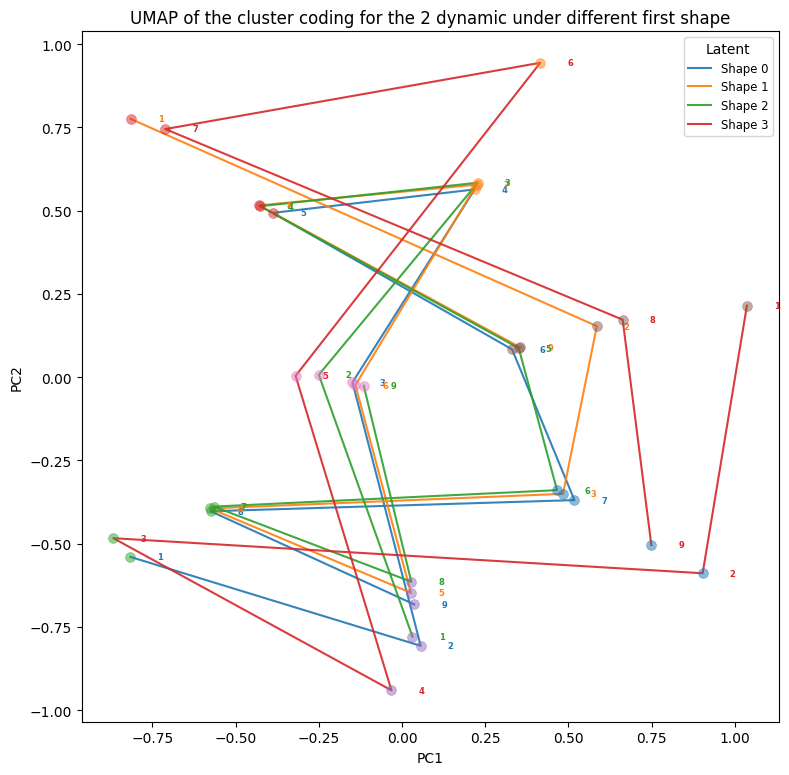

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

for k, S in projed_first_latent.items():
    if not (k == 0 or k == 1 or k == 2 or k == 3):
        continue

    latent_sequence = first_latent[k]
    # PC1/PC2 over time
    x = S[:, 0]
    y = S[:, 1]
    T_k = len(x)

    c_latent = latent_colors[k]

    # 1. plot the trajectory line in the latent's unique color
    ax.plot(
        x, y,
        linestyle="-",
        linewidth=1.5,
        color=c_latent,
        alpha=0.9,
        label=f"Shape {int(k)}",
    )

    # 2. label every timestep with its index (1,2,3,...)
    #    using a tiny offset so text isn't exactly on top of the line
    for t in range(T_k):
        col_dot = latent_colors[latent_sequence[t].item()]
        ax.scatter(
            x[t],
            y[t],
            marker="o",
            s=50,
            facecolors=col_dot,
            linewidths=0.5,
            zorder=4,
            alpha=0.5,
        )

        ax.text(
            x[t]+0.09,
            y[t],
            str(t + 1),          # <-- 1-based indexing
            color=c_latent,
            fontsize=6,
            ha="center",
            va="center",
            fontweight="bold",
        )

    # 3. emphasize start and end points for direction
    # ax.scatter(
    #     x[0], y[0],
    #     marker="o",
    #     s=50,
    #     facecolors=c_latent,
    #     edgecolors="k",
    #     linewidths=0.5,
    #     zorder=4,
    #     alpha=0.5,
    # )
    # ax.scatter(
    #     x[-1], y[-1],
    #     marker="s",
    #     s=50,
    #     facecolors=c_latent,
    #     edgecolors="k",
    #     linewidths=0.5,
    #     zorder=4,
    #     alpha=0.5,
    # )

# axes / legend
ax.set_xlabel("DIM1")
ax.set_ylabel("DIM2")
ax.set_title(f"MDS of the cluster coding for the {dynamic_to_look_at} dynamic under different first shape")
ax.set_aspect("equal")

ax.legend(fontsize="small", loc="best", title="Latent")

plt.tight_layout()
plt.show()


In [ ]:
only_prim_three_contexts = [context for context in all_contexts if context["next_primitive_offset"]==1]

In [ ]:
len(all_contexts)

In [ ]:
train_disent_loaders_1,val_disent_loaders_1 = make_disentanglement_loaders_with_timesteps(1,contexts=all_contexts)
train_disent_loaders_3,val_disent_loaders_3 = make_disentanglement_loaders_with_timesteps(3,contexts=all_contexts)

In [ ]:
prim_3_train_disent_loaders_3,prim_3_val_disent_loaders_3 = make_disentanglement_loaders_with_timesteps(3,contexts=only_prim_three_contexts)

In [ ]:
context_to_cluster,sorted_order

In [ ]:
classification_metric_train_loaders, classification_metric_val_loaders

In [ ]:
get_neurons_for_latent(config,
                       model,
                       classification_metric_train_loaders["position"][0],
                       classification_metric_val_loaders["position"][0],
                       0,
                       neurons_to_keep= get_neurons_of_clusters(cluster_to_neurons,clusters=[11,8,6,4,7,10]))



In [ ]:
get_neurons_for_latent(config,
                       model,
                       train_disent_loaders_3["primitive"][0],
                       val_disent_loaders_3["primitive"][0],
                       0,
                       neurons_to_keep= get_neurons_of_clusters(cluster_to_neurons,clusters=[11,8,6,4,7,10]))



In [ ]:
get_neurons_for_latent(config,
                       model,
                       classification_metric_train_loaders["primitive"][0],
                       classification_metric_val_loaders["primitive"][0],
                       0,
                       neurons_to_keep= get_neurons_except_from_clusters(cluster_to_neurons,clusters=[8,13,11,0,4,2,3]))


In [ ]:
get_neurons_for_latent(config,
                       model,
                       classification_metric_train_loaders["color"][0],
                       classification_metric_val_loaders["color"][0],
                       2,
                       neurons_to_keep= get_neurons_except_from_clusters(cluster_to_neurons,clusters=[15,7,6,10]))


In [ ]:
get_neurons_of_clusters(cluster_to_neurons,clusters=[1])

In [ ]:
get_neurons_for_latent(config,
                       model,
                       classification_metric_train_loaders["color"][0],
                       classification_metric_val_loaders["color"][0],
                       2,
                       neurons_to_keep= get_neurons_of_clusters(cluster_to_neurons,clusters=[11]))
